In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [24]:
df=pd.read_csv('./clean_data/cleaned_csvs/filtered_timeseries_fifa_players.csv')

In [25]:
df[df['short_name'] == "Iborra"]

,sofifa_id,player_url,short_name,long_name,overall,potential,value_eur,wage_eur,age,dob,...,LM,LW,LWB,RB,RM,RW,RWB,ST,year,GK
117,189560,https://sofifa.com/player/189560/vicente-iborr...,Iborra,Vicente Iborra de la Fuente,79,80,7500000.0,90000.0,26,1988-01-16,...,0,0,0,0,0,0,0,0,2015,NaN
2583,189560,https://sofifa.com/player/189560/vicente-iborr...,Iborra,Vicente Iborra de la Fuente,81,83,16000000.0,100000.0,27,1988-01-16,...,0,0,0,0,0,0,0,0,2016,NaN
5075,189560,https://sofifa.com/player/189560/vicente-iborr...,Iborra,Vicente Iborra de la Fuente,82,82,16000000.0,20000.0,28,1988-01-16,...,0,0,0,0,0,0,0,0,2017,NaN
7589,189560,https://sofifa.com/player/189560/vicente-iborr...,Iborra,Vicente Iborra de la Fuente,82,82,17000000.0,80000.0,29,1988-01-16,...,0,0,0,0,0,0,0,0,2018,NaN
10156,189560,https://sofifa.com/player/189560/vicente-iborr...,Iborra,Vicente Iborra de la Fuente,81,81,13000000.0,70000.0,30,1988-01-16,...,0,0,0,0,0,0,0,0,2019,NaN
12861,189560,https://sofifa.com/player/189560/vicente-iborr...,Iborra,Vicente Iborra de la Fuente,78,78,9000000.0,33000.0,31,1988-01-16,...,0,0,0,0,0,0,0,0,2020,NaN
15242,189560,https://sofifa.com/player/189560/vicente-iborr...,Iborra,Vicente Iborra de la Fuente,79,79,11500000.0,34000.0,32,1988-01-16,...,0,0,0,0,0,0,0,0,2021,0.0
17745,189560,https://sofifa.com/player/189560/vicente-iborr...,Iborra,Vicente Iborra de la Fuente,79,79,8500000.0,34000.0,33,1988-01-16,...,0,0,0,0,0,0,0,0,2022,NaN


In [26]:
df.columns[df.isnull().any()].tolist()

['value_eur', 'wage_eur', 'GK']

In [37]:
df['value_eur'].isna().sum()
df['value_eur']

0        100500000.0
1         79000000.0
2         52500000.0
3         36000000.0
4         46500000.0
            ...     
20011       140000.0
20012       200000.0
20013       180000.0
20014       200000.0
20015       140000.0
Name: value_eur, Length: 20016, dtype: float64

In [39]:
df.columnsm

AttributeError: 'Index' object has no attribute 'sum'

In [30]:
df['wage_eur'].isna().sum()

np.int64(105)

In [16]:
df['preferred_foot']

0         Left
1        Right
2        Right
3        Right
4        Right
         ...  
20011     Left
20012    Right
20013    Right
20014    Right
20015    Right
Name: preferred_foot, Length: 20016, dtype: str

In [32]:
df['body_type']
# drop this 

0           Normal (170-)
1           Normal (185+)
2           Normal (185+)
3           Normal (170-)
4        Normal (170-185)
               ...       
20011    Normal (170-185)
20012    Normal (170-185)
20013    Normal (170-185)
20014      Lean (170-185)
20015       Normal (170-)
Name: body_type, Length: 20016, dtype: str

In [8]:
dtypes_df = pd.DataFrame({'Column Name': df.columns, 'Data Type': df.dtypes.values})
df.columns.tolist()

['sofifa_id',
 'player_url',
 'short_name',
 'long_name',
 'overall',
 'potential',
 'value_eur',
 'wage_eur',
 'age',
 'dob',
 'height_cm',
 'weight_kg',
 'nationality_id',
 'nationality_name',
 'preferred_foot',
 'weak_foot',
 'skill_moves',
 'international_reputation',
 'work_rate',
 'body_type',
 'real_face',
 'pace',
 'shooting',
 'passing',
 'dribbling',
 'defending',
 'physic',
 'attacking_crossing',
 'attacking_finishing',
 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys',
 'skill_dribbling',
 'skill_curve',
 'skill_fk_accuracy',
 'skill_long_passing',
 'skill_ball_control',
 'movement_acceleration',
 'movement_sprint_speed',
 'movement_agility',
 'movement_reactions',
 'movement_balance',
 'power_shot_power',
 'power_jumping',
 'power_stamina',
 'power_strength',
 'power_long_shots',
 'mentality_aggression',
 'mentality_interceptions',
 'mentality_positioning',
 'mentality_vision',
 'mentality_penalties',
 'defending_marking_awareness',
 'defendin

In [7]:
#df=df.drop(columns='real_face')
#df=df.drop(columns='player_url')
#df['player_positions'] #one-hot encode
#df['international_reputation'] #treat as factor
df.columns

Index(['sofifa_id', 'player_url', 'short_name', 'long_name',
       'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur',
       'age', 'dob', 'height_cm', 'weight_kg', 'nationality_id',
       'nationality_name', 'preferred_foot', 'weak_foot', 'skill_moves',
       'international_reputation', 'work_rate', 'body_type', 'real_face',
       'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
       'attacking_crossing', 'attacking_finishing',
       'attacking_heading_accuracy', 'attacking_short_passing',
       'attacking_volleys', 'skill_dribbling', 'skill_curve',
       'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control',
       'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
       'movement_reactions', 'movement_balance', 'power_shot_power',
       'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
       'mentality_aggression', 'mentality_interceptions',
       'mentality_positioning', 'mentality_v

In [40]:
df['skill_curve']

0         89
1         88
2         85
3         80
4         80
          ..
126283    33
126284    53
126285    37
126286    36
126287    38
Name: skill_curve, Length: 126288, dtype: int64

In [33]:
messi_rows = df[df['short_name'].str.endswith('Messi', na=False)]
messi_rows['overall']

0         93
14380     94
28305     93
43908     93
59843     94
75898     94
92320     93
109181    93
Name: overall, dtype: int64

In [ ]:
fig = go.Figure(data=[go.Table(
    header=dict(values=list(df.columns),
                fill_color='paleturquoise',
                align='left'),
    cells=dict(values=[df[col] for col in df.columns],
               fill_color='lavender',
               align='left'))
])

fig.show()

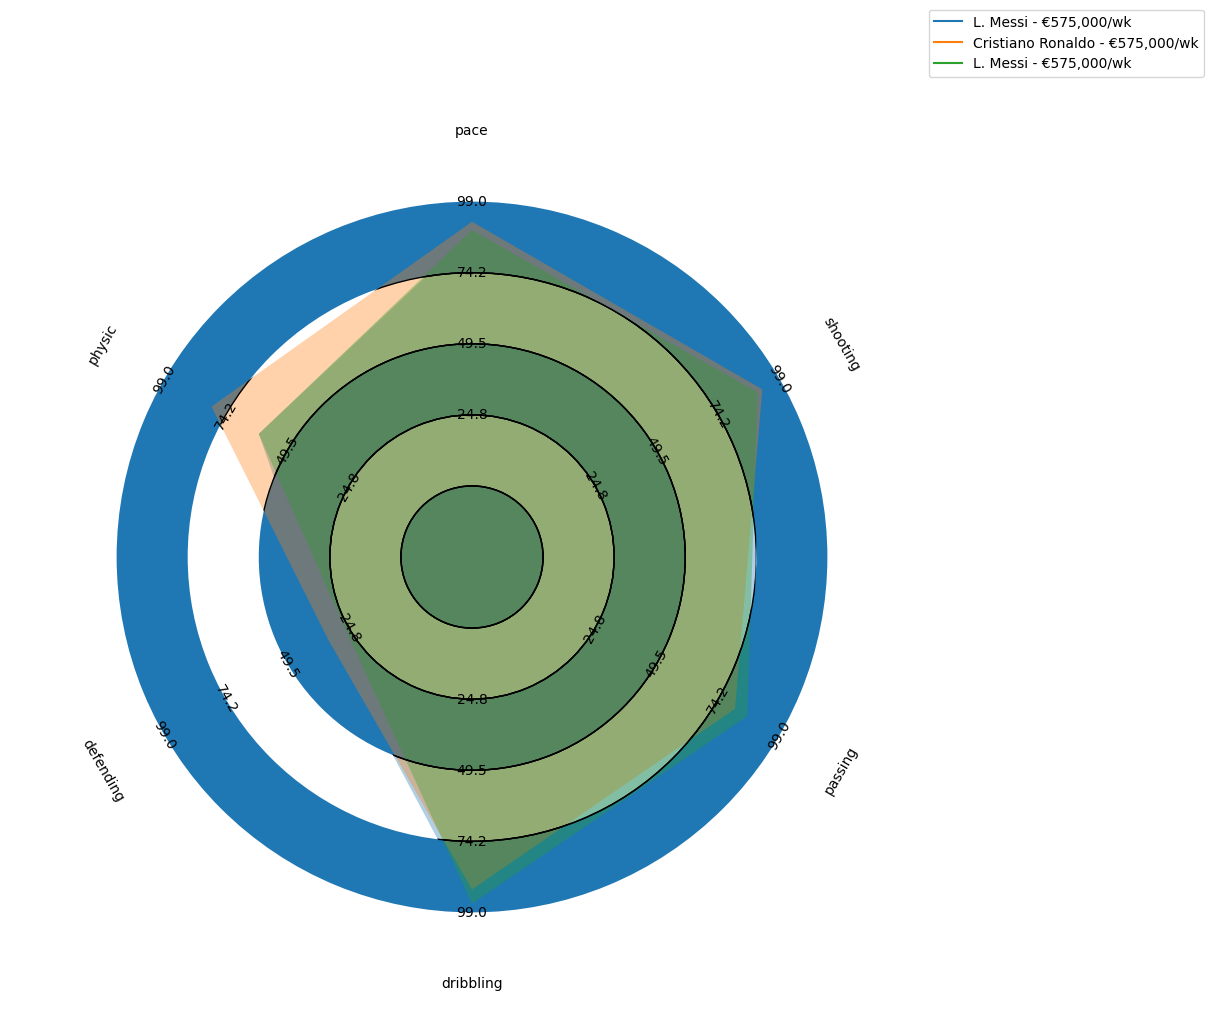

In [21]:
from mplsoccer import Radar,FontManager


top3 = df.sort_values("wage_eur", ascending=False).head(3).reset_index(drop=True)

# choose radar attributes (all 0–99 in Sofifa)
params = ["pace", "shooting", "passing", "dribbling", "defending", "physic"]

# ranges for Sofifa attributes
lower = [0] * len(params)
upper = [99] * len(params)


radar = Radar(params=params, min_range=lower, max_range=upper)

fig, ax = radar.setup_axis()
radar.draw_circles(ax=ax)

# colors for each player
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

for i, row in top3.iterrows():
    values = row[params].tolist()
    radar.draw_radar(
        values,
        ax=ax,
        kwargs_radar={"facecolor": colors[i], "alpha": 0.35},
        kwargs_rings={"facecolor": "None"},
    )

# draw labels
radar.draw_range_labels(ax=ax)
radar.draw_param_labels(ax=ax)

# legend with names and wages
labels = [
    f"{row['short_name']} - €{int(row['wage_eur']):,}/wk"
    for _, row in top3.iterrows()
]
for label, color in zip(labels, colors):
    ax.plot([], [], color=color, label=label)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()


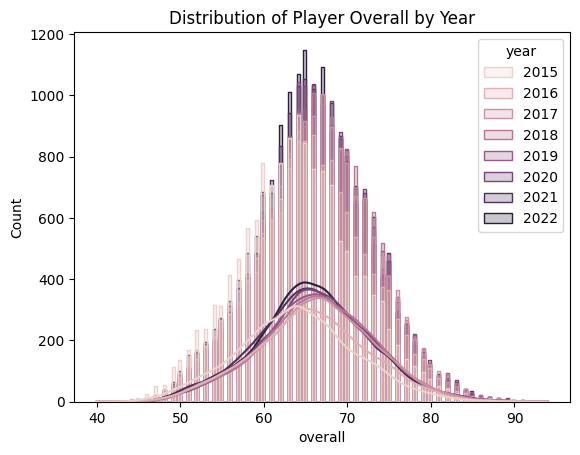

In [8]:
sns.histplot(data=df, x='overall', hue='year', element='step', kde=True)
plt.title('Distribution of Player Overall by Year')
plt.show()


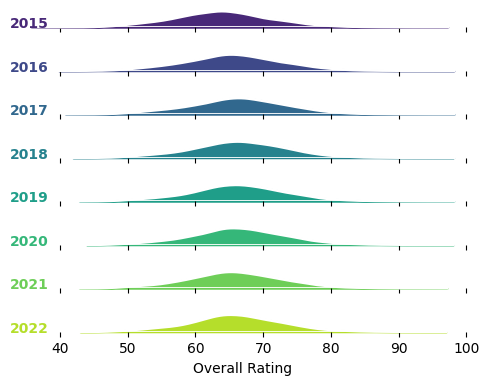

In [79]:
g = sns.FacetGrid(df, row="year", hue="year", aspect=10, height=0.5, palette="viridis")

plt.title('Distribution of Player Overall by Year')
# 3. Plot the KDEs (Density plots)
g.map(sns.kdeplot, "overall", clip_on=False, fill=True, alpha=1, lw=1.5, bw_method=.2)
g.map(sns.kdeplot, "overall", clip_on=False, color="w", lw=2, bw_method=.2)

# 4. Add a horizontal line for each plot
g.map(plt.axhline, y=0, lw=2, color="white")

# 5. Define and use a simple function to label the plot in facet
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)

g.map(label, "overall")

# 6. Final adjustments
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.xlabel("Overall Rating")
plt.tight_layout()
plt.show()


In [57]:
sacha_boey = df[df['short_name'].str.endswith('Boey', na=False)].head(3)
sacha_boey_values = sacha_boey[params].iloc[2].tolist()
sacha_boey_values

[86.0, 43.0, 60.0, 68.0, 63.0, 67.0]

In [66]:
k_debruyne = df[df['short_name'].str.endswith('Bruyne',na=False)].head(1)
debruyne_values = k_debruyne[params].iloc[0].tolist()


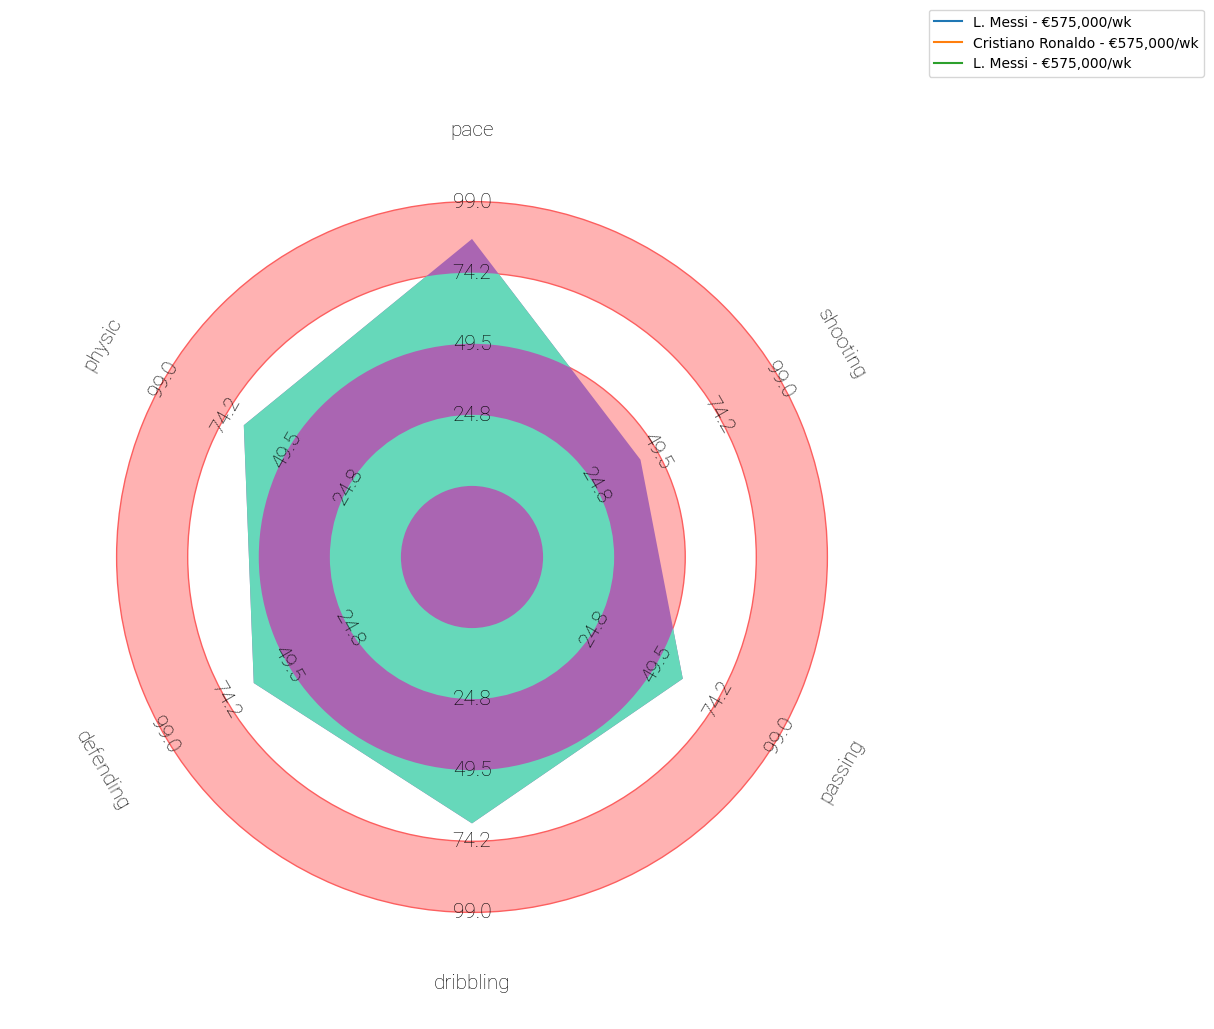

In [80]:
URL4 = 'https://raw.githubusercontent.com/googlefonts/roboto/main/src/hinted/Roboto-Thin.ttf'
robotto_thin = FontManager(URL4)


fig, ax = radar.setup_axis()  # format axis as a radar
rings_inner = radar.draw_circles(ax=ax, facecolor='#ffb2b2', edgecolor='#fc5f5f')  # draw circles
radar_output = radar.draw_radar(sacha_boey_values, ax=ax,
                                kwargs_radar={'facecolor': '#aa65b2'},
                                kwargs_rings={'facecolor': '#66d8ba'})  # draw the radar
radar_poly, rings_outer, vertices = radar_output
range_labels = radar.draw_range_labels(ax=ax, fontsize=15,
                                       fontproperties=robotto_thin.prop)  # draw the range labels
param_labels = radar.draw_param_labels(ax=ax, fontsize=15,
                                       fontproperties=robotto_thin.prop)  # draw the param labels


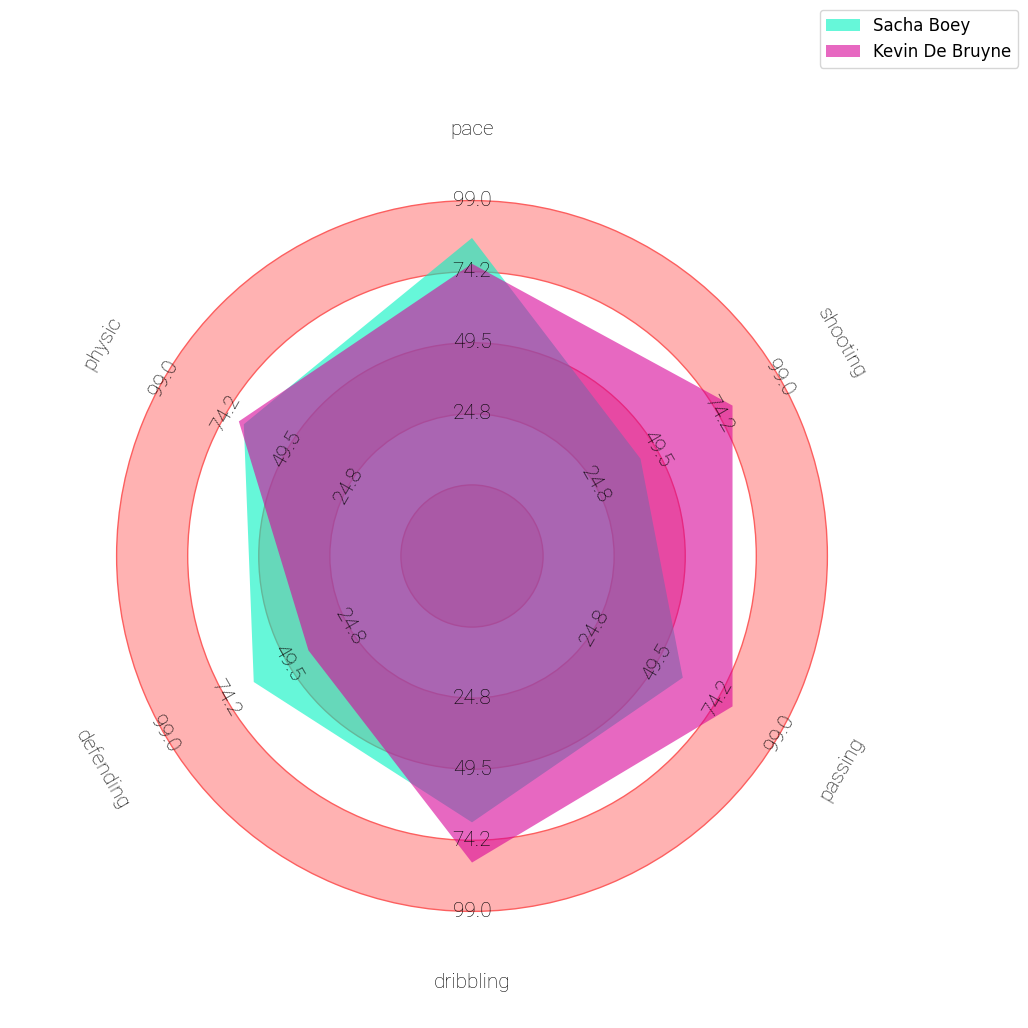

In [83]:
fig, ax = radar.setup_axis()
rings_inner = radar.draw_circles(ax=ax, facecolor='#ffb2b2', edgecolor='#fc5f5f')
radar_output = radar.draw_radar_compare(sacha_boey_values, debruyne_values, ax=ax,
                                        kwargs_radar={'facecolor': '#00f2c1', 'alpha': 0.6},
                                        kwargs_compare={'facecolor': '#d80499', 'alpha': 0.6})
radar_poly, radar_poly2, vertices1, vertices2 = radar_output
range_labels = radar.draw_range_labels(ax=ax, fontsize=15,
                                       fontproperties=robotto_thin.prop)
param_labels = radar.draw_param_labels(ax=ax, fontsize=15,
                                       fontproperties=robotto_thin.prop)

ax.legend([radar_poly, radar_poly2], 
          ['Sacha Boey', 'Kevin De Bruyne'],
          loc='upper right',
          bbox_to_anchor=(1.1, 1.1),
          fontsize=12)

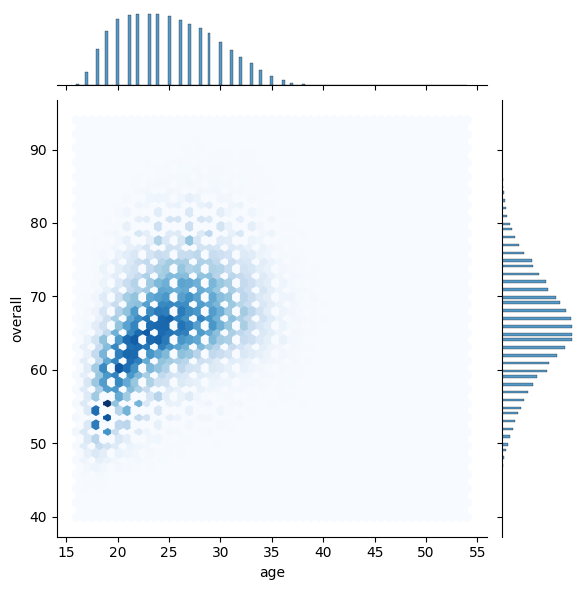

In [68]:
sns.jointplot(data=df, x='age', y='overall', kind='hex', cmap='Blues')
plt.show()

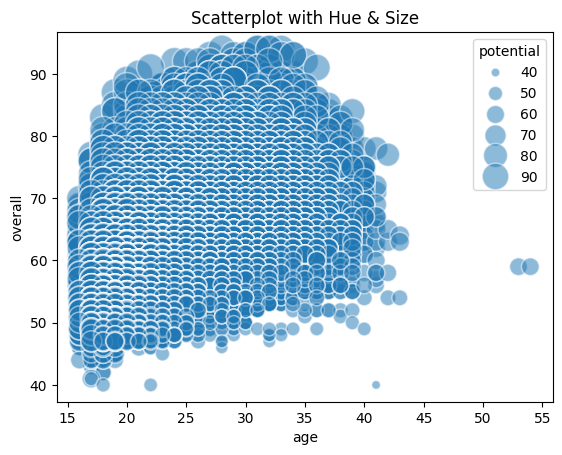

In [72]:
sns.scatterplot(data=df, x='age', y='overall', sizes=(40, 400), alpha=.5,
              palette='viridis', size='potential')
plt.title('Scatterplot with Hue & Size')
plt.show()


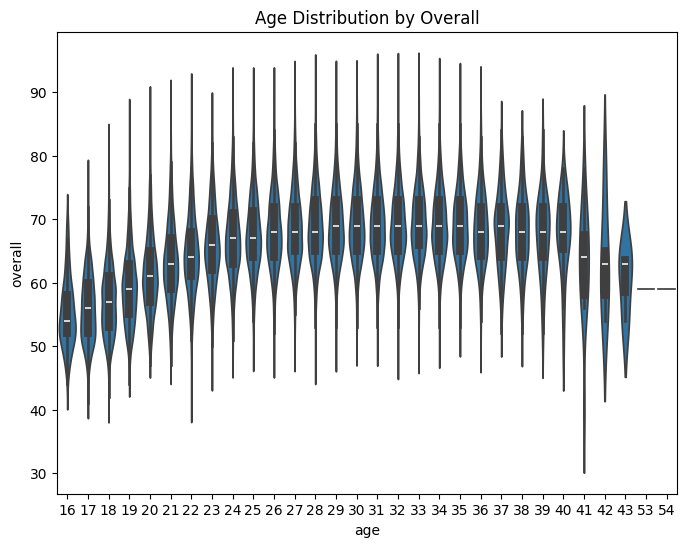

In [75]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x="age", y="overall")
plt.title("Age Distribution by Overall")
plt.show()

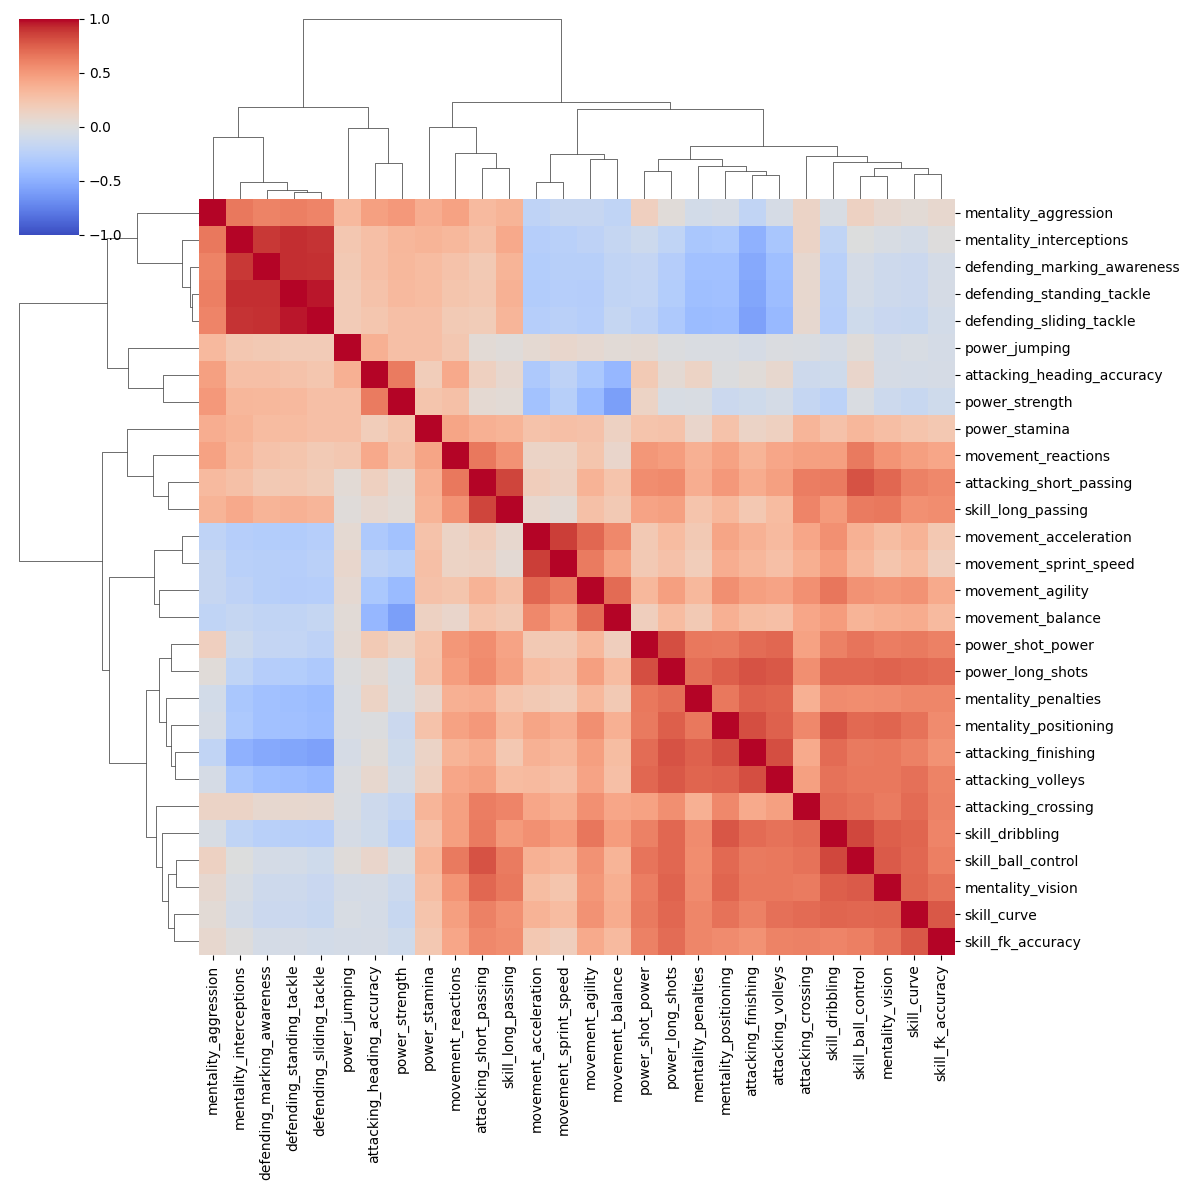

In [77]:
cols = ['attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 
        'attacking_short_passing', 'attacking_volleys', 'skill_dribbling', 
        'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 
        'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 
        'movement_agility', 'movement_reactions', 'movement_balance', 
        'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 
        'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 
        'mentality_positioning', 'mentality_vision', 'mentality_penalties', 
        'defending_marking_awareness', 'defending_standing_tackle', 
        'defending_sliding_tackle']

# 2. Select data and calculate correlation
# Assuming your DataFrame is named 'df'
corr_matrix = df[cols].corr()

# 3. Create clustered heatmap
sns.clustermap(corr_matrix, 
               cmap='coolwarm', 
               vmin=-1, vmax=1, 
               figsize=(12, 12), 
               annot=False) # annot=True can be messy for many columns

plt.show()